In [2]:
#imports 
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

In [3]:
# ⚙️ DEVICE CONFIG
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🔧 HYPERPARAMETERS
LEARNING_RATE = 0.03  # learning rate
BATCH_SIZE = 64 # batch size
EPOCHS = 600 # number of epochs
HIDDEN_LAYERS = 2 # number of hidden layers
TRAIN_RATIO = 0.6 # ratio of training data
NUM_CLASSES = 2 # number of classes
NOISE = 1.0  # std deviation for clusters

In [ ]:
import plotly.express as px
from sklearn.datasets import make_blobs
import pandas as pd

# Generate 3D blobs
X, y = make_blobs(n_samples=10000, centers=NUM_CLASSES, n_features=3,
                  cluster_std=NOISE, random_state=42)

# Convert to DataFrame for Plotly
df = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\temporalData.csv')

# Interactive Plot
#fig = px.scatter_3d(df, x="X1", y="X2", z="Z", color="Label", opacity=0.6,
                   # title="Interactive 3D Blob Dataset",
                   # color_continuous_scale="Viridis")
#fig.show()


In [12]:
df

,indicator,date,seen,cumulative_seen,days_since_last_seen_x,seen_streak,rolling_seen_ratio_14d,rolling_seen_std_14d,high_activity_not_seen_ratio_14d,low_activity_seen_ratio_14d,...,max_unseen_streak,mean_seen_interval,std_seen_interval,days_since_last_seen_y,high_activity_not_seen_count,high_activity_not_seen_ratio,low_activity_seen_count,low_activity_seen_ratio,seen_score,unseen_risk
0,102.129.153.158,2024-01-01,0,0,0.0,0,0.000000,0.000000,1.0,0.0,...,431,21.000000,0.000000,52,503,0.996040,0,0.0,-4.201980,211.803960
1,102.129.153.158,2024-01-02,0,0,0.0,0,0.000000,0.000000,1.0,0.0,...,431,21.000000,0.000000,52,503,0.996040,0,0.0,-4.201980,211.803960
2,102.129.153.158,2024-01-03,0,0,0.0,0,0.000000,0.000000,1.0,0.0,...,431,21.000000,0.000000,52,503,0.996040,0,0.0,-4.201980,211.803960
3,102.129.153.158,2024-01-04,0,0,0.0,0,0.000000,0.000000,1.0,0.0,...,431,21.000000,0.000000,52,503,0.996040,0,0.0,-4.201980,211.803960
4,102.129.153.158,2024-01-05,0,0,0.0,0,0.000000,0.000000,1.0,0.0,...,431,21.000000,0.000000,52,503,0.996040,0,0.0,-4.201980,211.803960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110085,www.shorturl.at/,2025-05-15,1,58,0.0,1,0.357143,0.497245,0.0,0.0,...,370,2.258621,1.559845,3,446,0.883168,0,0.0,24.241584,163.816832
110086,www.shorturl.at/,2025-05-16,1,59,0.0,2,0.428571,0.513553,0.0,0.0,...,370,2.258621,1.559845,3,446,0.883168,0,0.0,24.241584,163.816832
110087,www.shorturl.at/,2025-05-17,0,59,1.0,0,0.428571,0.513553,0.0,0.0,...,370,2.258621,1.559845,3,446,0.883168,0,0.0,24.241584,163.816832
110088,www.shorturl.at/,2025-05-18,0,59,2.0,0,0.428571,0.513553,0.0,0.0,...,370,2.258621,1.559845,3,446,0.883168,0,0.0,24.241584,163.816832


In [14]:
df.columns

Index(['indicator', 'date', 'seen', 'cumulative_seen',
       'days_since_last_seen_x', 'seen_streak', 'rolling_seen_ratio_14d',
       'rolling_seen_std_14d', 'high_activity_not_seen_ratio_14d',
       'low_activity_seen_ratio_14d', 'rolling_seen_ratio_7d',
       'seen_ratio_diff', 'rolling_obs_14d', 'rolling_obs_7d',
       'obs_ratio_spike', 'seen_streak_prev', 'recent_drop_flag',
       'volatility_ratio', 'total_seen', 'seen_ratio', 'seen_std',
       'max_seen_streak', 'max_unseen_streak', 'mean_seen_interval',
       'std_seen_interval', 'days_since_last_seen_y',
       'high_activity_not_seen_count', 'high_activity_not_seen_ratio',
       'low_activity_seen_count', 'low_activity_seen_ratio', 'seen_score',
       'unseen_risk'],
      dtype='object')

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Drop non-numeric columns and rows with NaN
X_df = df.select_dtypes(include=[np.number]).dropna()
y_df = df.loc[X_df.index, 'seen']  # Example: using 'seen' as target

# Fit RandomForest for feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_df, y_df)

importances = pd.Series(rf.feature_importances_, index=X_df.columns)
importances.sort_values(ascending=False)


seen                                0.403228
seen_streak                         0.315584
days_since_last_seen_x              0.078202
rolling_seen_ratio_7d               0.049745
rolling_obs_7d                      0.038763
high_activity_not_seen_ratio_14d    0.020745
rolling_seen_ratio_14d              0.019360
volatility_ratio                    0.009784
seen_streak_prev                    0.009532
cumulative_seen                     0.008102
rolling_obs_14d                     0.006929
obs_ratio_spike                     0.005807
seen_ratio_diff                     0.004818
rolling_seen_std_14d                0.004539
seen_score                          0.003816
high_activity_not_seen_count        0.003583
seen_std                            0.003309
max_seen_streak                     0.002215
mean_seen_interval                  0.002166
low_activity_seen_ratio_14d         0.001624
total_seen                          0.001489
high_activity_not_seen_ratio        0.001374
recent_dro

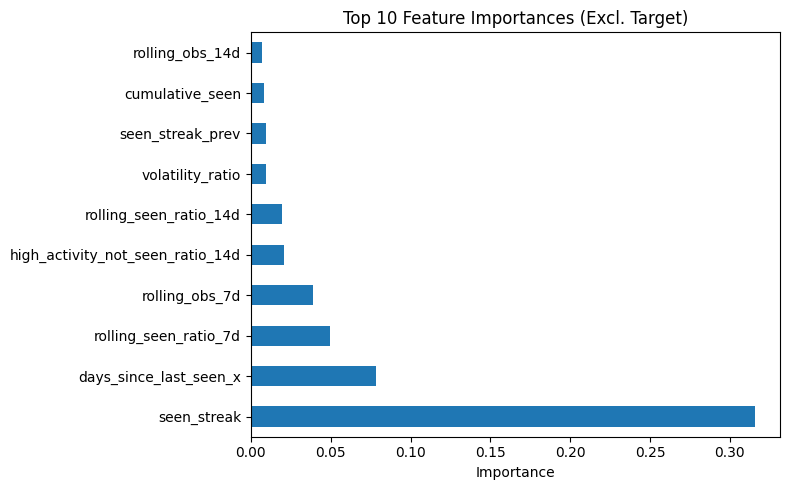

In [19]:
# Plot the top 10 most important features from the RandomForest, excluding the target
top_n = 10
importances_no_target = importances.drop('seen', errors='ignore')
importances_no_target.nlargest(top_n).plot(kind='barh', figsize=(8, 5), title='Top 10 Feature Importances (Excl. Target)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [13]:
X.shape

(10000, 3)

Number of Clusters: 3
Silhouette Score: 0.4882
Davies-Bouldin Index: 0.7163
Calinski-Harabasz Score: 129.9506


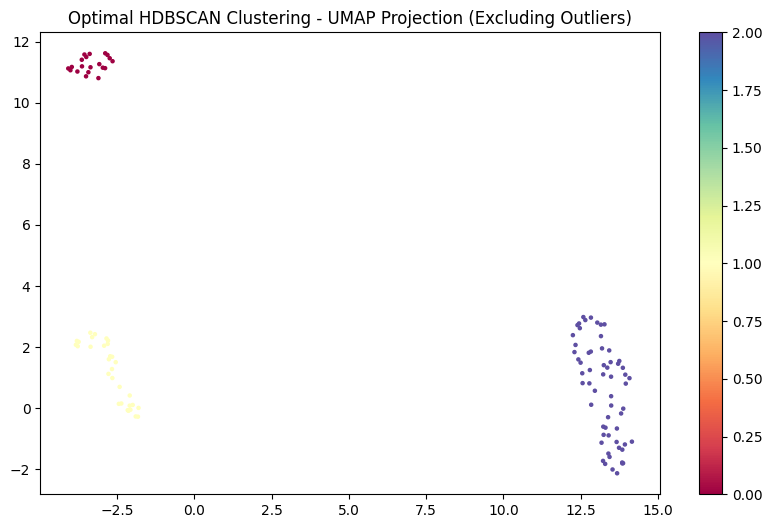

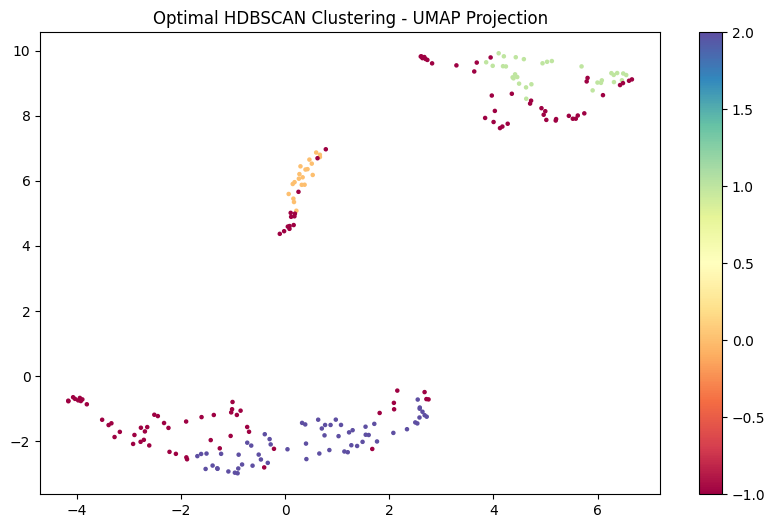

Seen Statistics by Cluster:    Cluster      mean       std  min  max  median
0       -1  0.038651  0.192764    0    1     0.0
1        0  0.016733  0.128274    0    1     0.0
2        1  0.002811  0.052942    0    1     0.0
3        2  0.027041  0.162206    0    1     0.0


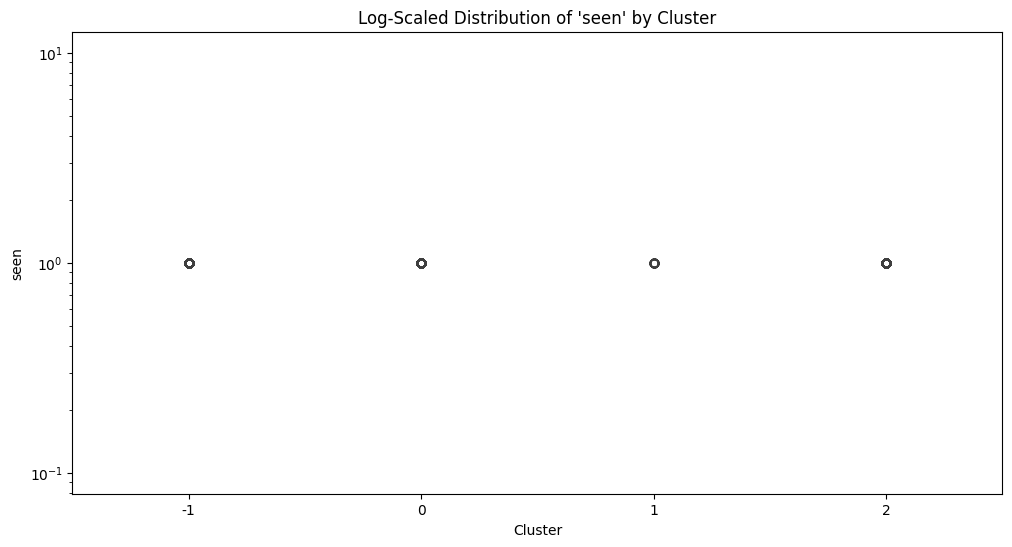

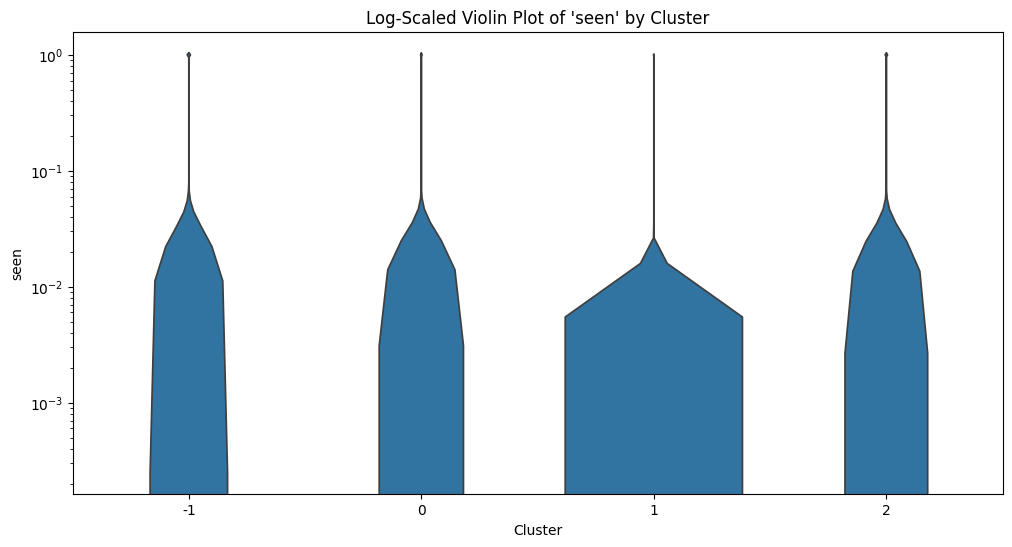

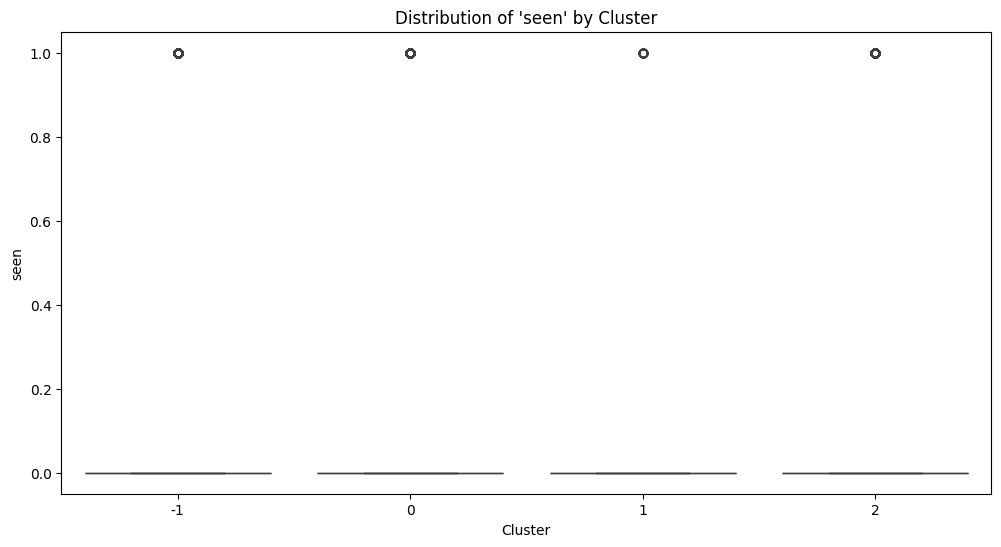

Cluster Profiles:         seen_streak_mean                               seen_streak_std  \
                    mean       std       min       max            mean   
Cluster                                                                  
-1              0.192901  0.723208  0.001980  6.661386        0.592202   
 0              0.019604  0.004889  0.011881  0.029703        0.156749   
 1              0.002811  0.001426  0.001980  0.007921        0.051713   
 2              0.031651  0.009438  0.011881  0.055446        0.198800   

                                       seen_streak_max            ...  \
              std       min        max            mean       std  ...   
Cluster                                                           ...   
-1       1.702631  0.044499  14.617144        4.198113  7.891430  ...   
 0       0.032672  0.108459   0.229537        1.900000  0.640723  ...   
 1       0.011683  0.044499   0.088734        1.000000  0.000000  ...   
 2       0.041627  0.1084

In [71]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', module='sklearn.utils.deprecation')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import hdbscan
import umap.umap_ as umap
from collections import Counter

# Load Data
data = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\temporalData.csv')

# Select Relevant Features
features = ['seen_streak', 'days_since_last_seen_x', 'rolling_seen_ratio_7d', 
            'rolling_obs_7d', 'high_activity_not_seen_ratio_14d', 'rolling_seen_ratio_14d', 
            'volatility_ratio', 'seen_streak_prev', 'obs_ratio_spike', 'seen_ratio_diff']

# Aggregate Data by IP Address
X = data.groupby('indicator')[features].agg(['mean', 'std', 'max', 'min']).fillna(0)
X.columns = ['_'.join(col).strip() for col in X.columns.values]

# Feature Engineering: Interaction Features
X['streak_volatility'] = X['seen_streak_mean'] * X['volatility_ratio_mean']
X['obs_spike_diff'] = X['obs_ratio_spike_mean'] - X['seen_ratio_diff_mean']
X['rolling_ratio_diff'] = X['rolling_seen_ratio_7d_mean'] / (X['rolling_obs_7d_mean'] + 1e-6)

# Standardize Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Optimal HDBSCAN Configuration
min_cluster_size = 10
min_samples = 10
metric = 'euclidean'

# Apply HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric=metric)
labels = clusterer.fit_predict(X_scaled)

# Cluster Analysis
valid_labels = labels[labels != -1]
valid_data = X_scaled[labels != -1]
num_clusters = len(np.unique(valid_labels))
print(f"Number of Clusters: {num_clusters}")

# Calculate Validation Metrics
if len(np.unique(valid_labels)) > 1:
    silhouette = silhouette_score(valid_data, valid_labels)
    db_index = davies_bouldin_score(valid_data, valid_labels)
    ch_score = calinski_harabasz_score(valid_data, valid_labels)
    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Davies-Bouldin Index: {db_index:.4f}")
    print(f"Calinski-Harabasz Score: {ch_score:.4f}")

# UMAP Visualization - Excluding Outliers
umap_reducer = umap.UMAP()
X_umap = umap_reducer.fit_transform(valid_data)

plt.figure(figsize=(10, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=valid_labels, cmap='Spectral', s=5)
plt.title("Optimal HDBSCAN Clustering - UMAP Projection (Excluding Outliers)")
plt.colorbar()
plt.show()

umap_reducer = umap.UMAP()
X_umap = umap_reducer.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='Spectral', s=5)
plt.title("Optimal HDBSCAN Clustering - UMAP Projection")
plt.colorbar()
plt.show()

# Relating Clusters to Target Variable 'seen'

# Mapping Cluster Labels to Original Data
label_map = dict(zip(X.index, labels))

data['Cluster'] = data['indicator'].map(label_map)
# Apply Cluster Mapping
label_map = dict(zip(X.index, labels))
data['Cluster'] = data['indicator'].map(label_map)

# Aggregate 'seen' by cluster
seen_stats = data.groupby('Cluster')['seen'].agg(['mean', 'std', 'min', 'max', 'median']).reset_index()
print("Seen Statistics by Cluster:", seen_stats)

# Enhanced Visualization: Log-scaled Boxplot of 'seen' by Cluster
plt.figure(figsize=(12, 6))
sns.boxplot(x='Cluster', y='seen', data=data)
plt.yscale('log')
plt.title("Log-Scaled Distribution of 'seen' by Cluster")
plt.show()

# Violin Plot for Enhanced Visualization
plt.figure(figsize=(12, 6))
sns.violinplot(x='Cluster', y='seen', data=data)
plt.yscale('log')
plt.title("Log-Scaled Violin Plot of 'seen' by Cluster")
plt.show()
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='Cluster', y='seen', data=data)
plt.title("Distribution of 'seen' by Cluster")
plt.show()

cluster_profiles = X.copy()
cluster_profiles['Cluster'] = labels

# Calculate Cluster Statistics
cluster_stats = cluster_profiles.groupby('Cluster').agg(['mean', 'std', 'min', 'max'])
print("Cluster Profiles:", cluster_stats)

# Cluster Sizes
cluster_counts = Counter(labels[labels != -1])
print("Cluster Sizes:", cluster_counts)

# Outlier Analysis
outliers = np.where(labels == -1)[0]
print(f"Number of Outliers: {len(outliers)}")


In [ ]:
# 🟠 DATA PREPROCESSING
# Correct way for NumPy -> Torch
X = torch.tensor(X, dtype=torch.float32)  # shape [N, D]
y = torch.tensor(y, dtype=torch.long)     # shape [N]


# 🟠 TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=TRAIN_RATIO, random_state=42)

# DATALOADERS
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)

In [8]:
# 🧠 MODEL
class MultiClassClassifier(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=16, hidden_layers=HIDDEN_LAYERS, output_dim=NUM_CLASSES):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
        layers += [nn.Linear(hidden_dim, output_dim)]
        self.model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.model(x)

model = MultiClassClassifier().to(device)
loss_fn = nn.CrossEntropyLoss()  # multi-class loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [9]:
# 🚂 TRAINING LOOP
for epoch in range(EPOCHS):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        y_logits = model(X_batch)
        loss = loss_fn(y_logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")

Epoch 000 | Loss: 0.2714
Epoch 050 | Loss: 0.0626
Epoch 100 | Loss: 0.1487
Epoch 150 | Loss: 0.0738
Epoch 200 | Loss: 0.1198
Epoch 250 | Loss: 0.1713
Epoch 300 | Loss: 0.0804
Epoch 350 | Loss: 0.0776
Epoch 400 | Loss: 0.0335
Epoch 450 | Loss: 0.0959
Epoch 500 | Loss: 0.2085
Epoch 550 | Loss: 0.0580


In [10]:
# ✅ EVALUATION
model.eval()
with torch.no_grad():
    X_test, y_test = X_test.to(device), y_test.to(device)
    y_logits = model(X_test)
    y_pred = torch.argmax(y_logits, dim=1)
    acc = (y_pred == y_test).float().mean()
    print(f"\n🎯 Test Accuracy: {acc:.4f}")


🎯 Test Accuracy: 0.9538


In [18]:
import plotly.graph_objects as go

def plot_decision_boundary_3d_points(model, X, y, device):
    # Predict on full input
    model.eval()
    with torch.no_grad():
        X_device = X.to(device)
        preds = model(X_device)
        preds = torch.argmax(preds, dim=1)

    # Plot predicted points colored by model output
    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=X[:, 0].cpu().numpy(),
        y=X[:, 1].cpu().numpy(),
        z=X[:, 2].cpu().numpy(),
        mode='markers',
        marker=dict(
            size=4,
            color=preds.cpu().numpy(),  # model-predicted class
            colorscale='Viridis',
            opacity=0.8
        ),
        name="Model Predictions"
    ))

    # Optionally overlay actual labels for comparison
    fig.add_trace(go.Scatter3d(
        x=X[:, 0].cpu().numpy(),
        y=X[:, 1].cpu().numpy(),
        z=X[:, 2].cpu().numpy(),
        mode='markers',
        marker=dict(
            size=2,
            color=y.cpu().numpy(),  # ground truth
            colorscale='curl',
            opacity=0.95,
            symbol="square-open"
        ),
        name="True Labels"
    ))

    fig.update_layout(
        title="3D Model Predictions (Colored Points)",
        scene=dict(
            xaxis_title='X1',
            yaxis_title='X2',
            zaxis_title='Z',
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()


In [19]:
plot_decision_boundary_3d_points(model, X_test, y_test, device)